# Model changing uncertainty and predict new responses

Let both the mean and spread depend on a covariate, fit the model, and compare
uncertainty about the mean with uncertainty about a new response. This notebook
is self-contained. For the building blocks, see {doc}`11-model-building`.

## Generate data with changing spread

We use $\mu_i=\beta_0+\beta_1 x_i$ and
$\sigma_i=\exp(\gamma_0+\gamma_1 x_i)$ in
$y_i\sim\mathcal{N}(\mu_i,\sigma_i^2)$. A linear log-scale predictor keeps the
standard deviation positive.

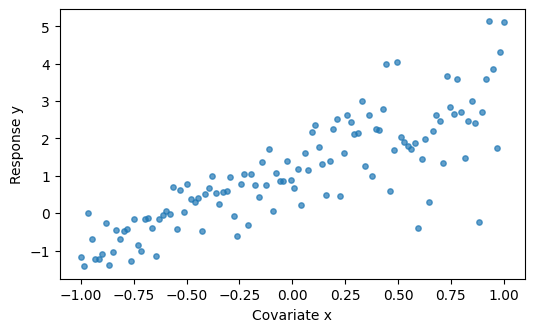

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import tensorflow_probability.substrates.jax.distributions as tfd

import liesel.goose as gs
import liesel.model as lsl

x_data = jnp.linspace(-1.0, 1.0, 120)
true_mean = 1.0 + 2.0 * x_data
true_scale = jnp.exp(-0.4 + 0.7 * x_data)
y_data = true_mean + true_scale * jax.random.normal(jax.random.key(8), (120,))

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.scatter(x_data, y_data, s=15, alpha=0.7)
ax.set(xlabel="Covariate x", ylabel="Response y")
plt.show()

The spread grows with `x`. A constant residual scale would hide this structure.
We can express the changing scale with the same calculator variables used for
the mean.

## Define mean and log-scale predictors

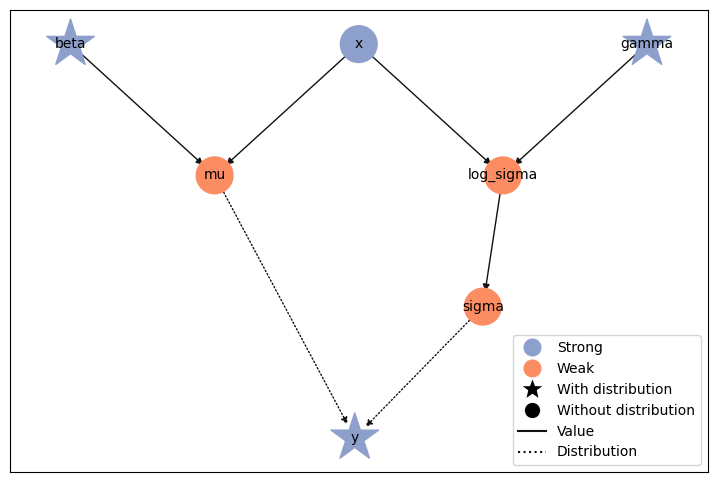

In [2]:
beta = lsl.Var.new_param(
    jnp.zeros(2), lsl.Dist(tfd.Normal, loc=0.0, scale=2.5), name="beta"
)
gamma = lsl.Var.new_param(
    jnp.zeros(2), lsl.Dist(tfd.Normal, loc=0.0, scale=1.0), name="gamma"
)
x = lsl.Var.new_obs(x_data, name="x")
mu = lsl.Var.new_calc(lambda x, b: b[0] + b[1] * x, x, beta, name="mu")
log_sigma = lsl.Var.new_calc(lambda x, g: g[0] + g[1] * x, x, gamma, name="log_sigma")
sigma = lsl.Var.new_calc(jnp.exp, log_sigma, name="sigma")
y = lsl.Var.new_obs(y_data, lsl.Dist(tfd.Normal, loc=mu, scale=sigma), name="y")
model = lsl.Model(y)
model.plot(width=9, height=6)

The graph has two paths into the response distribution. Both reuse `x`, but
each has its own coefficients and prior. We place normal priors directly on
the log-scale coefficients. This is a modeling choice, not a transformation
of some previously specified prior on `sigma`; see
{doc}`../../model-transformations` for that distinction.

## Fit with Goose

Put both coefficient vectors into one NUTS block. Small random perturbations
give the chains different starting positions. All parameters are unconstrained.

In [3]:
for parameter in model.parameters.values():
    parameter.inference = gs.MCMCSpec(
        gs.NUTSKernel,
        kernel_group="regression",
        jitter_dist=tfd.Normal(loc=0.0, scale=0.1),
    )

results = gs.LieselMCMC(model).run_for_epochs(
    seed=31, num_chains=4, adaptation=500, posterior=500, show_progress=False
)
samples = results.get_posterior_samples()

liesel.goose.engine - INFO - Initializing kernels...


liesel.goose.engine - INFO - Done


liesel.goose.engine - INFO - Finished warmup


The fit supplies draws for both `beta` and `gamma`. `Model.predict` will
propagate those draws through the graph; the model's current parameter values
are not a substitute for them.

## Check the fit before predicting

In [4]:
summary = gs.Summary(results, which=["mean", "sd", "rhat", "ess_bulk", "ess_tail"])
summary.to_dataframe().round(3)

,var_fqn,kernel,var_index,sample_size,mean,sd,ess_bulk,ess_tail,rhat
variable,,,,,,,,,
beta,beta[0],kernel_00,"(0,)",2000,1.107,0.071,1535.689,1476.308,1.002
beta,beta[1],kernel_00,"(1,)",2000,2.137,0.111,1586.530,1398.596,1.006
gamma,gamma[0],kernel_00,"(0,)",2000,-0.361,0.068,1935.003,1370.393,1.000
gamma,gamma[1],kernel_00,"(1,)",2000,0.657,0.104,1667.677,1404.754,1.001


Check that the chains agree (`rhat` close to 1) and that effective sample sizes
are sufficient for the quantities you want to estimate. These checks should
be read with the traces, not treated as proof of convergence.

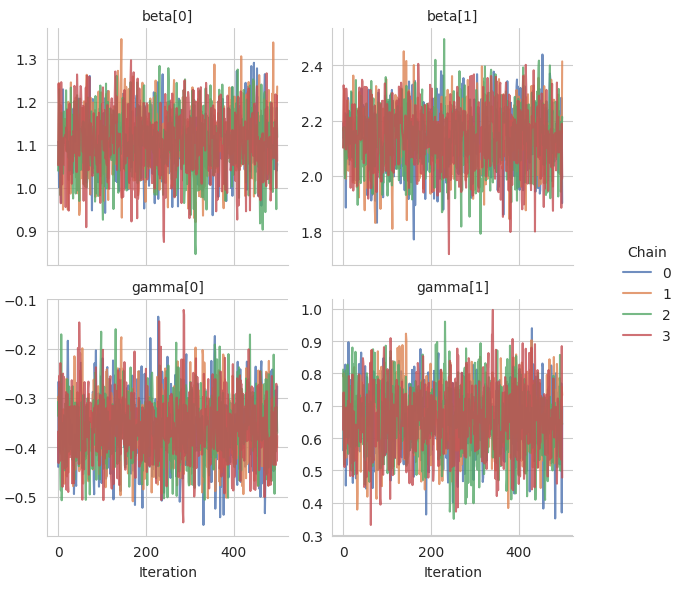

In [5]:
gs.plot_trace(results, ncol=2)
plt.show()

Look for overlapping chains without long drifts or stuck segments. If your fit
has poor agreement, persistent structure, or sampler errors, investigate it
before interpreting the following plots. See {class}`~liesel.goose.Summary`
and {doc}`../md/01c-transform` for further diagnostics and sampling examples.

## Predict the mean and spread on a grid

In [6]:
x_grid = jnp.linspace(-1.0, 1.0, 60)
predicted = model.predict(samples, predict=["mu", "sigma"], newdata={"x": x_grid})
print({name: value.shape for name, value in predicted.items()})

{'mu': (4, 500, 60), 'sigma': (4, 500, 60)}


Each result has axes **chain × draw × grid point**, with shape `(4, 500, 60)`.
`mu` describes the mean and `sigma` the standard deviation for each draw.
Neither is a random new response. Selecting these outputs evaluates their
parental submodel, so no replacement response data are needed yet.

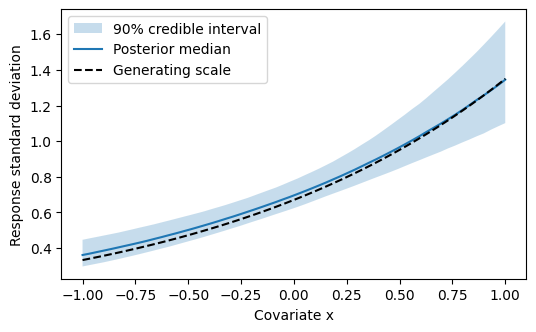

In [7]:
probs = jnp.array([0.05, 0.5, 0.95])
mean_q = jnp.quantile(predicted["mu"], probs, axis=(0, 1))
scale_q = jnp.quantile(predicted["sigma"], probs, axis=(0, 1))

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.fill_between(
    x_grid, scale_q[0], scale_q[2], alpha=0.25, label="90% credible interval"
)
ax.plot(x_grid, scale_q[1], label="Posterior median")
ax.plot(x_data, true_scale, linestyle="--", color="black", label="Generating scale")
ax.set(xlabel="Covariate x", ylabel="Response standard deviation")
ax.legend()
plt.show()

The increasing scale accounts for the growing response spread. The band
describes uncertainty about that scale, not a range for future responses.
The dashed curve is available only because we simulated these data.

## Simulate new responses

In [8]:
replicated = model.sample(
    shape=(),
    seed=jax.random.key(29),
    posterior_samples=samples,
    newdata={"x": x_grid, "y": jnp.zeros_like(x_grid)},
)
print(replicated["y"].shape)
response_q = jnp.quantile(replicated["y"], probs, axis=(0, 1))

(4, 500, 60)


`shape=()` requests one dataset per posterior draw. Both parameter vectors are
provided, so only response variation is added. The zero-valued response
placeholder sets the new length to 60; its values are replaced by simulation.
The result again has shape `(4, 500, 60)`. Use a fresh random key for another
replication; see {doc}`../../model-simulation` for prior and conditional draws.

## Compare mean uncertainty with response variation

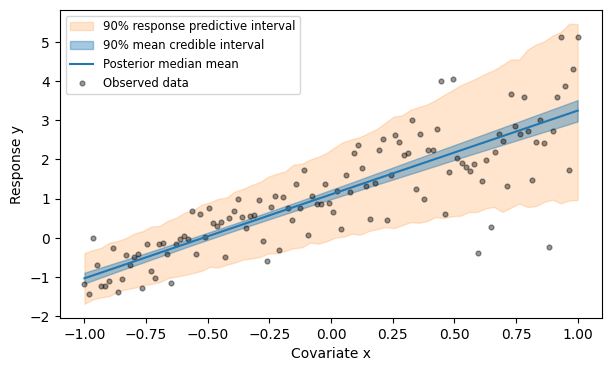

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.fill_between(
    x_grid,
    response_q[0],
    response_q[2],
    color="C1",
    alpha=0.2,
    label="90% response predictive interval",
)
ax.fill_between(
    x_grid,
    mean_q[0],
    mean_q[2],
    color="C0",
    alpha=0.4,
    label="90% mean credible interval",
)
ax.plot(x_grid, mean_q[1], color="C0", label="Posterior median mean")
ax.scatter(x_data, y_data, s=12, color="black", alpha=0.4, label="Observed data")
ax.set(xlabel="Covariate x", ylabel="Response y")
ax.legend(fontsize="small")
plt.show()

The mean band reflects parameter uncertainty. The wider predictive band also
includes random response variation and grows with the fitted standard deviation.
Both intervals are pointwise: each applies at one grid value, not to a whole
curve simultaneously. Overlap with the observed data is a useful visual check,
not a held-out assessment of predictive accuracy.

Use {doc}`../../model-prediction` for other named quantities and
{doc}`../../model-distributions` for pointwise log likelihoods.